# Atividade de vendas no Brasil

# 1.) Numpy

In [85]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("../../data/vendas_brasil_1.csv")

### Informações sobre as colunas do dataframe

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [38]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


## A. Criando Arrays

### Utilizando colunas como numpy arrays para realizar operações vetorizadas

In [39]:
preco_unitario = df["preco_unitario"].to_numpy()
custo_unitario = df["custo_unitario"].to_numpy()
quantidade = df["quantidade"].to_numpy()
desconto_pct = df["desconto_pct"].to_numpy()
receita = df["receita_total"].to_numpy()
frete = df["frete"].to_numpy()

## B. Cálculos com operações vetorizadas

In [40]:
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto*desconto_pct/100
custo_total = custo_unitario * quantidade
lucro_estimado = valor_bruto-valor_desconto-custo_total

## C. Máscaras booleanas

### Vendas cuja receita foi maior do que a média das receitas

In [41]:
df[receita>receita.mean()]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
11,2022-11-27,11,São Paulo,Site Web,Esportes,Raquete,João Vieira,Prata,130.74,101.92,...,12,0.7,2167.48,6.80,4.52,14.0,False,False,True,False
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,7,5.9,7945.96,47.18,3.52,12.0,False,False,False,True
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,6,24.7,3314.59,48.72,2.94,4.0,False,True,False,False
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,14,5.9,11246.38,68.85,4.47,13.0,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37593,2023-12-31,2,Manaus,Site Web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,8,19.2,3636.00,77.13,4.02,17.0,False,False,False,False
37603,2023-12-31,9,Rio de Janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,5,5.4,4554.52,18.19,3.49,3.0,False,True,False,True
37605,2023-12-31,3,Fortaleza,Marketplace,Esportes,Tapete de Yoga,Carla Mendes,Bronze,352.25,256.20,...,10,4.7,3369.62,42.94,3.52,7.0,False,True,False,False
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,7,10.9,1960.18,30.99,3.50,6.0,False,True,True,False


### Vendas cujo custo total foi maior do que a receita, ou seja, vendas com prejuízo

In [42]:
df[custo_total>receita]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
8,2022-05-02,5,São Paulo,Site Web,Alimentação,Whey Protein,Bruno Souza,Prata,31.18,26.55,...,9,20.2,224.94,17.42,4.46,6.0,False,True,False,False
24,2022-07-11,7,Recife,App Mobile,Vestuário,Jaqueta,Ana Lima,Bronze,186.43,151.02,...,14,25.4,1954.39,15.96,5.00,2.0,False,True,False,False
76,2023-07-10,7,Salvador,Loja Física,Livros,Machine Learning,Inês Nunes,Bronze,99.36,80.05,...,7,25.4,518.23,12.31,5.00,4.0,True,True,False,False
77,2022-06-11,6,Curitiba,Loja Física,Vestuário,Jaqueta,Inês Nunes,Bronze,102.96,85.35,...,7,19.4,580.45,27.94,4.03,14.0,False,False,False,False
101,2022-05-09,5,Manaus,Marketplace,Eletrônicos,Smartwatch,Bruno Souza,Ouro,980.24,776.73,...,12,26.0,8647.88,6.16,5.00,19.0,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37559,2023-12-31,6,Curitiba,Marketplace,Alimentação,Whey Protein,Ana Lima,Ouro,48.61,40.37,...,2,20.8,76.98,5.40,3.97,11.0,False,True,False,False
37565,2023-12-31,2,Fortaleza,Loja Física,Livros,Álgebra Linear,Elisa Costa,Prata,91.83,72.67,...,9,24.8,620.42,38.21,3.95,10.0,False,True,False,False
37582,2023-12-31,8,Manaus,Marketplace,Esportes,Garrafa Térmica,João Vieira,Ouro,160.19,128.62,...,4,24.3,487.17,32.66,1.99,8.0,False,False,False,False
37589,2023-12-31,4,Rio de Janeiro,App Mobile,Eletrônicos,Fone Bluetooth,Fábio Ramos,Bronze,899.09,734.88,...,5,24.4,3409.52,20.08,4.04,8.0,True,False,False,True


### Vendas com desconto alto (acima de 25%)

In [43]:
df[desconto_pct>25]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
24,2022-07-11,7,Recife,App Mobile,Vestuário,Jaqueta,Ana Lima,Bronze,186.43,151.02,...,14,25.4,1954.39,15.96,5.00,2.0,False,True,False,False
33,2022-02-28,2,Curitiba,Site Web,Vestuário,Calça Jeans,Diego Ferreira,Prata,148.35,92.37,...,14,25.2,1561.69,17.22,4.46,18.0,False,False,False,False
34,2023-05-26,5,Recife,Marketplace,Livros,Estatística Aplicada,Ana Lima,Prata,50.11,32.90,...,8,25.5,297.64,10.33,4.03,16.0,False,False,False,False
68,2022-01-02,1,Manaus,Marketplace,Vestuário,Tênis,Elisa Costa,Bronze,94.40,63.81,...,13,25.3,1328.46,10.83,3.98,16.0,True,False,True,False
76,2023-07-10,7,Salvador,Loja Física,Livros,Machine Learning,Inês Nunes,Bronze,99.36,80.05,...,7,25.4,518.23,12.31,5.00,4.0,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37516,2023-12-31,1,Salvador,App Mobile,Alimentação,Whey Protein,Inês Nunes,Ouro,92.40,61.39,...,12,25.5,1197.94,4.56,4.98,14.0,False,True,True,False
37533,2023-12-31,5,Belo Horizonte,App Mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,...,5,25.7,179.58,13.15,4.49,14.0,True,True,False,False
37576,2023-12-31,2,Porto Alegre,App Mobile,Livros,Cálculo Vol.1,Fábio Ramos,Ouro,53.69,34.35,...,3,25.4,120.45,10.82,4.01,9.0,False,False,False,False
37584,2023-12-31,1,Manaus,Loja Física,Alimentação,Azeite,Bruno Souza,Bronze,58.44,46.95,...,13,25.8,772.56,9.29,4.53,9.0,False,False,True,False


## D. Agregações

In [44]:
receita.mean() # receita média

np.float64(1891.6881729005502)

In [45]:
receita.max() # receita máxima

np.float64(58430.28)

In [46]:
receita.min() # receita mínima

np.float64(3.7)

In [47]:
lucro_estimado.mean() # lucro médio

np.float64(342.0324771624532)

In [48]:
custo_total[custo_total>receita].shape # quantidade de vendas com prejuízo

(2168,)

### A partir das análises feitas acima, podemos concluir que as receitas das vendas variam bastante, de 3.70 reais até 58430.28 reais, apresentando uma média de 342 reais. Além disso, pode-se observar que a quantidade de vendas com prejuízo - 160 - não é tão relevante, dada a quantidade de vendas totais presente no dataset - 37617.

# 2.) Pandas

## A. Exploração inicial sobre o dataset

In [49]:
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False


In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  str    
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  str    
 3   canal_venda         37567 non-null  str    
 4   categoria           37617 non-null  str    
 5   produto             37617 non-null  str    
 6   vendedor            37577 non-null  str    
 7   fidelidade_cliente  37617 non-null  str    
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  float64
 16  prazo_entrega_d

In [51]:
df.describe()

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000


In [52]:
df.shape

(37617, 21)

In [53]:
df.isna().sum()

data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64

####
1- O dataset apresenta 37617 linhas e 21 colunas.

2- Há dados faltantes nas colunas canal_venda, vendedor, margem_pct, frete, avaliacao_cliente e prazo_entrega_dias.

3- As colunas mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente, prazo_entrega_dias são numéricas.

4- As colunas canal_venda, categoria, fidelidade_cliente parecem ser categóricas.

## B. Limpeza e Tratamento

#### Converter data_venda para datetime

In [54]:
df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce") # algumas entradas não estão devidamente formatadas, por isso usamos errors="coerce" para limpá-las.

#### As colunas canal_venda e vendedor recebem "desconhecido" em entradas ausentes. A coluna margem_pct substitui entradas ausentes por 100*(1 - custo/preço), já que assim obtemos a margem em percentual. A coluna frete, por sua vez, recebe 0.

In [55]:
df = df.fillna(value={"canal_venda": "desconhecido", "vendedor": "desconhecido", "frete": 0})
df["margem_pct"] = np.where(df["margem_pct"].isna(), 100*(1 - df["custo_unitario"]/df["preco_unitario"]), df["margem_pct"])

#### Padronizar as colunas categóricas fidelidade_cliente e canal_venda

In [56]:
df["fidelidade_cliente"].unique() # há diferentes entradas para valores de mesmo significado semântico

<ArrowStringArray>
['Diamante',   'Bronze',    'Prata',     'Ouro',     'ouro',    'prata',
   'bronze', 'DIAMANTE',    'PRATA',   'BRONZE',     'OURO', 'diamante']
Length: 12, dtype: str

In [57]:
df["fidelidade_cliente"] = df["fidelidade_cliente"].apply(lambda x : str.lower(x)) # vamos deixar todas lower case
df["fidelidade_cliente"].unique()

<ArrowStringArray>
['diamante', 'bronze', 'prata', 'ouro']
Length: 4, dtype: str

In [58]:
df["canal_venda"].unique()

<ArrowStringArray>
[  'App Mobile',     'Site Web',  'Loja Física',  'Marketplace',
   'Televendas',   'APP Mobile',     'site web',     'Site web',
   'app mobile',      'SiteWeb', 'desconhecido',  'Loja Fisica',
   'App mobile',  'loja física',  'Loja fisica']
Length: 15, dtype: str

In [59]:
df["canal_venda"] = df["canal_venda"].apply(lambda x : str.lower(x)) # vamos deixar todas lower case
df["canal_venda"] = np.where(df["canal_venda"]=="siteweb", "site web", df["canal_venda"]) # conversão 'siteweb' -> 'site web'
df["canal_venda"] = np.where(df["canal_venda"]=="loja física", "loja fisica", df["canal_venda"]) # conversão 'loja física' -> 'loja fisica'
df["canal_venda"].unique()

<ArrowStringArray>
[  'app mobile',     'site web',  'loja fisica',  'marketplace',
   'televendas', 'desconhecido']
Length: 6, dtype: str

### Padronizar a coluna cidade

In [152]:
cidades_padrao = {
    "sp": "são paulo",
    "s. paulo": "são paulo",
    "sao paulo": "são paulo",
    "curtiba": "curitiba",
    "rj": "rio de janeiro",
    "rio": "rio de janeiro",
    "bh": "belo horizonte",
    "b. horizonte": "belo horizonte",
    "slavador": "salvador",
    "rio de janeiro": "rio de janeiro",
    "são paulo": "são paulo",
    "manaus": "manaus",
    "curitiba": "curitiba",
    "goiânia": "goiânia",
    "fortaleza": "fortaleza",
    "porto alegre": "porto alegre",
    "recife": "recife",
    "belo horizonte": "belo horizonte",
    "salvador": "salvador"
}
df["cidade"] = df["cidade"].apply(lambda x: str.lower(x))
df["cidade"] = df["cidade"].apply(lambda x: str.strip(x))
df["cidade"] = df["cidade"].apply(lambda x: cidades_padrao.get(x))
df["cidade"].unique()

<ArrowStringArray>
['rio de janeiro',         'manaus',        'goiânia',      'fortaleza',
 'belo horizonte',         'recife',      'são paulo',   'porto alegre',
       'salvador',       'curitiba']
Length: 10, dtype: str

## C. Criação de novas colunas

#### Criando novas colunas: lucro_total, ano_venda e preco_acima_media

In [61]:
df["lucro_total"] = df["receita_total"] - df["quantidade"]*df["custo_unitario"]
df["ano_venda"] = df["data_venda"].apply(lambda x: x.year)
df["preco_acima_media"] = np.where(df["preco_unitario"]>df["preco_unitario"].mean(), True, False)
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,lucro_total,ano_venda,preco_acima_media
0,2022-04-13,4,rio de janeiro,app mobile,Eletrônicos,Notebook,Bruno Souza,diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,1315.98,2022.0,True
1,2023-03-12,3,manaus,site web,Vestuário,Camiseta,Elisa Costa,bronze,187.48,135.15,...,0.00,4.98,19.0,True,False,False,False,254.53,2023.0,False
2,2022-09-28,9,goiânia,app mobile,Vestuário,Tênis,João Vieira,bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,198.90,2022.0,False
3,2022-04-17,4,fortaleza,site web,Vestuário,Calça Jeans,Carla Mendes,bronze,145.86,88.53,...,20.49,4.50,16.0,False,True,False,False,618.60,2022.0,False
4,2022-03-13,3,belo horizonte,app mobile,Esportes,Bicicleta,João Vieira,bronze,133.92,107.25,...,22.89,3.49,13.0,False,True,False,False,0.39,2022.0,False


## D. Filtros

#### 1.) Quais vendas tiveram receita acima da média?
#### Das mais de 37.000 vendas, apenas 9000 estão acima da média das receitas, o que indica a possibilidade de existência de outliers na coluna receita, ou seja, vendas com receitas muito acima da faixa esperada.

In [62]:
df[df["receita_total"]>df["receita_total"].mean()]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,lucro_total,ano_venda,preco_acima_media
0,2022-04-13,4,rio de janeiro,app mobile,Eletrônicos,Notebook,Bruno Souza,diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,1315.98,2022.0,True
11,2022-11-27,11,são paulo,site web,Esportes,Raquete,João Vieira,prata,130.74,101.92,...,6.80,4.52,14.0,False,False,True,False,944.44,2022.0,False
15,2022-04-10,4,salvador,marketplace,Eletrônicos,Smartphone,Ana Lima,bronze,1213.88,843.05,...,47.18,3.52,12.0,False,False,False,True,2044.61,2022.0,True
17,2022-05-11,5,belo horizonte,app mobile,Eletrônicos,Smartwatch,Elisa Costa,prata,732.37,536.37,...,48.72,2.94,4.0,False,True,False,False,96.37,2022.0,True
20,2022-12-10,12,recife,site web,Eletrônicos,Smartphone,Inês Nunes,prata,603.40,394.18,...,68.85,4.47,13.0,False,True,True,False,5727.86,2022.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37593,2023-12-31,2,manaus,site web,Eletrônicos,Tablet,Gabi Alves,ouro,565.19,385.88,...,77.13,4.02,17.0,False,False,False,False,548.96,2023.0,True
37603,2023-12-31,9,rio de janeiro,app mobile,Eletrônicos,Tablet,Inês Nunes,prata,963.50,608.11,...,18.19,3.49,3.0,False,True,False,True,1513.97,2023.0,True
37605,2023-12-31,3,fortaleza,marketplace,Esportes,Tapete de Yoga,Carla Mendes,bronze,352.25,256.20,...,42.94,3.52,7.0,False,True,False,False,807.62,2023.0,True
37615,2023-12-31,11,são paulo,site web,Esportes,Tapete de Yoga,João Vieira,bronze,197.09,167.23,...,30.99,3.50,6.0,False,True,True,False,789.57,2023.0,False


#### Quais vendas tiveram devolução?
#### Apenas 3532 vendas tiveram devolução.

In [63]:
df[df["devolucao"]]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,lucro_total,ano_venda,preco_acima_media
1,2023-03-12,3,manaus,site web,Vestuário,Camiseta,Elisa Costa,bronze,187.48,135.15,...,0.00,4.98,19.0,True,False,False,False,254.53,2023.0,False
2,2022-09-28,9,goiânia,app mobile,Vestuário,Tênis,João Vieira,bronze,76.11,61.40,...,7.98,3.47,NaN,True,True,False,False,198.90,2022.0,False
7,2023-09-07,9,manaus,app mobile,Alimentação,Mel Orgânico,Inês Nunes,prata,35.72,21.62,...,24.98,3.03,18.0,True,False,False,False,51.63,2023.0,False
18,2023-10-24,10,manaus,site web,Vestuário,Camiseta,Carla Mendes,prata,65.73,41.26,...,56.61,NaN,16.0,True,True,False,False,99.72,2023.0,False
21,2023-05-07,5,são paulo,loja fisica,Eletrônicos,Smartwatch,Gabi Alves,bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,1562.81,2023.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37522,2023-12-31,11,salvador,marketplace,Esportes,Bicicleta,Carla Mendes,bronze,195.87,161.39,...,6.95,2.95,7.0,True,True,True,False,969.54,2023.0,False
37525,2023-12-31,11,curitiba,loja fisica,Esportes,Luva de Box,Ana Lima,prata,248.42,183.21,...,8.57,2.04,13.0,True,True,True,False,1157.31,2023.0,False
37533,2023-12-31,5,belo horizonte,app mobile,Alimentação,Granola,Henrique Dias,prata,48.60,36.51,...,13.15,4.49,14.0,True,True,False,False,-2.97,2023.0,False
37583,2023-12-31,2,manaus,loja fisica,Eletrônicos,Smartwatch,Henrique Dias,bronze,846.16,697.37,...,14.03,1.00,10.0,True,True,False,True,684.49,2023.0,True


#### Quais vendas são de eletrônicos?
#### Há 7515 vendas de produtos da categoria eletrônicos no dataset.

In [64]:
df[df["categoria"]=="Eletrônicos"]

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,lucro_total,ano_venda,preco_acima_media
0,2022-04-13,4,rio de janeiro,app mobile,Eletrônicos,Notebook,Bruno Souza,diamante,739.39,561.75,...,8.68,4.92,5.0,False,True,False,False,1315.98,2022.0,True
15,2022-04-10,4,salvador,marketplace,Eletrônicos,Smartphone,Ana Lima,bronze,1213.88,843.05,...,47.18,3.52,12.0,False,False,False,True,2044.61,2022.0,True
17,2022-05-11,5,belo horizonte,app mobile,Eletrônicos,Smartwatch,Elisa Costa,prata,732.37,536.37,...,48.72,2.94,4.0,False,True,False,False,96.37,2022.0,True
20,2022-12-10,12,recife,site web,Eletrônicos,Smartphone,Inês Nunes,prata,603.40,394.18,...,68.85,4.47,13.0,False,True,True,False,5727.86,2022.0,True
21,2023-05-07,5,são paulo,loja fisica,Eletrônicos,Smartwatch,Gabi Alves,bronze,892.83,660.58,...,9.89,1.05,18.0,True,True,False,True,1562.81,2023.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37589,2023-12-31,4,rio de janeiro,app mobile,Eletrônicos,Fone Bluetooth,Fábio Ramos,bronze,899.09,734.88,...,20.08,4.04,8.0,True,False,False,True,-264.88,2023.0,True
37593,2023-12-31,2,manaus,site web,Eletrônicos,Tablet,Gabi Alves,ouro,565.19,385.88,...,77.13,4.02,17.0,False,False,False,False,548.96,2023.0,True
37600,2023-12-31,12,fortaleza,app mobile,Eletrônicos,Tablet,Henrique Dias,ouro,212.67,167.18,...,7.09,2.05,6.0,False,True,True,False,169.67,2023.0,False
37603,2023-12-31,9,rio de janeiro,app mobile,Eletrônicos,Tablet,Inês Nunes,prata,963.50,608.11,...,18.19,3.49,3.0,False,True,False,True,1513.97,2023.0,True


## E.) Agregações

#### Abaixo vemos que a categoria Eletrônicos apresentou a maior receita total

In [65]:
df.groupby("categoria")["receita_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

#### Abaixo vemos que o canal site web teve a maior quantidade de vendas.

In [66]:
df.groupby("canal_venda")["quantidade"].sum().sort_values(ascending=False)

canal_venda
site web        85091
app mobile      83839
loja fisica     56705
marketplace     41707
televendas      13726
desconhecido      373
Name: quantidade, dtype: int64

#### Abaixo vemos que a categoria Eletrônicos teve o maior lucro total.

In [67]:
df.groupby("categoria")["lucro_total"].sum().sort_values(ascending=False)

categoria
Eletrônicos    12192275.55
Esportes        3133196.10
Vestuário       1849449.96
Livros          1225652.89
Alimentação      903986.63
Name: lucro_total, dtype: float64

## F. Merge

In [68]:
df_cidades = pd.DataFrame({"cidade": ["rio de janeiro", "manaus", "goiânia", "fortaleza",
                                      "belo horizonte", "recife", "são paulo",
                                      "porto alegre", "salvador","cutitiba", "sp", "rj", "bh"],
                           "regiao": ["sudeste", "norte", "centro-oeste", "nordeste", "sudeste",
                                      "nordeste", "sudeste", "sul", "nordeste", "sul", "sudeste", "sudeste", "sudeste"]})
df = df.merge(df_cidades, on="cidade", how="left")
df.head()

,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,lucro_total,ano_venda,preco_acima_media,regiao
0,2022-04-13,4,rio de janeiro,app mobile,Eletrônicos,Notebook,Bruno Souza,diamante,739.39,561.75,...,4.92,5.0,False,True,False,False,1315.98,2022.0,True,sudeste
1,2023-03-12,3,manaus,site web,Vestuário,Camiseta,Elisa Costa,bronze,187.48,135.15,...,4.98,19.0,True,False,False,False,254.53,2023.0,False,norte
2,2022-09-28,9,goiânia,app mobile,Vestuário,Tênis,João Vieira,bronze,76.11,61.40,...,3.47,NaN,True,True,False,False,198.90,2022.0,False,centro-oeste
3,2022-04-17,4,fortaleza,site web,Vestuário,Calça Jeans,Carla Mendes,bronze,145.86,88.53,...,4.50,16.0,False,True,False,False,618.60,2022.0,False,nordeste
4,2022-03-13,3,belo horizonte,app mobile,Esportes,Bicicleta,João Vieira,bronze,133.92,107.25,...,3.49,13.0,False,True,False,False,0.39,2022.0,False,sudeste


#### Nesta seção foi necessário realizar uma ampla limpeza e padronização dos dados para que os resultados das operações seguintes não fossem comprometidos. Em seguida, criamos novas colunas para nos auxiliar na exploração dos dados. Finalmente, criamos filtros e agrupamentos para gerar análises mais claras  e obter respostas sobre o comportamento geral dos dados. Fizemos ainda um merge com um dataframe auxiliar para obter as regiões de cada venda de acordo com suas respectivas cidades.

# 3.) Seaborn

### A. Gráfico de Barras: receita total por categoria

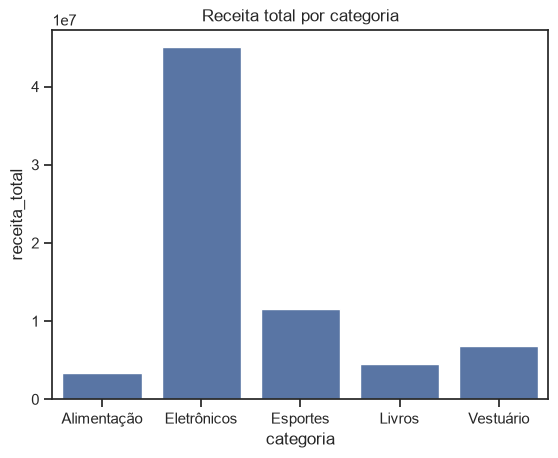

In [86]:
df_categoria_receita = df.groupby("categoria", as_index=False)["receita_total"].sum()
sns.barplot(data=df_categoria_receita, x="categoria", y="receita_total")
plt.title("Receita total por categoria")
plt.show()

#### A partir do gráfico acima, podemos observar que os produtos da categoria Eletrônicos apresentam receita consideravelmente superior do que os produtos das outras categorias.

## B. Gráfico de linha: Evolução da receita por mês

In [87]:
df["data_venda"].min()

Timestamp('2022-01-01 00:00:00')

In [88]:
df["data_venda"].max()

Timestamp('2023-12-31 00:00:00')

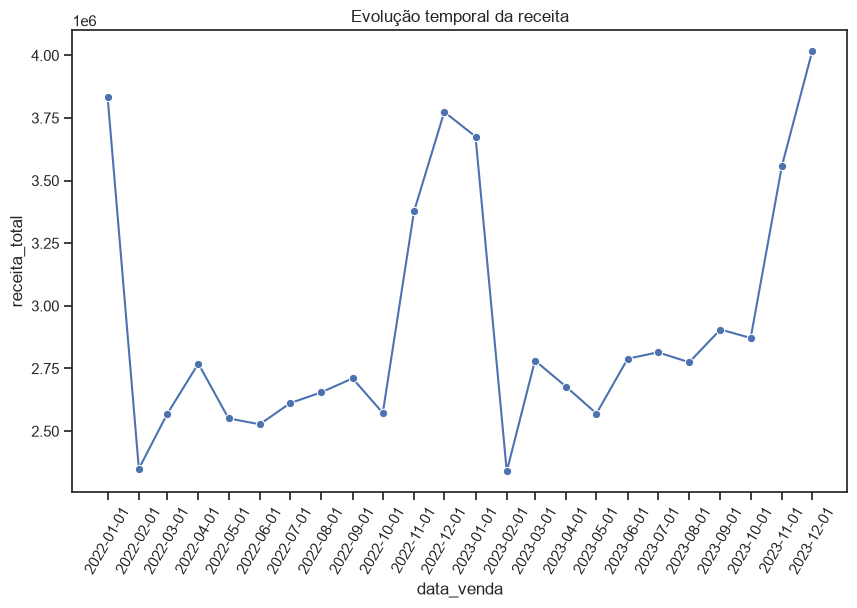

In [146]:
df_receita_tempo = df[["data_venda", "receita_total"]]
df_receita_tempo.dropna(subset=["data_venda"], inplace=True)
df_receita_tempo["data_venda"] = df_receita_tempo["data_venda"].dt.to_period('M').dt.to_timestamp() # extraindo mês e ano de cada data
df_receita_tempo = df_receita_tempo.groupby("data_venda", as_index=False)["receita_total"].sum()
fig, ax = plt.subplots(figsize=(10,6))
sns.lineplot(data=df_receita_tempo, x="data_venda", y="receita_total", marker="o")
ax.set_xticks(df_receita_tempo["data_venda"])
plt.xticks(rotation=60)
plt.title("Evolução temporal da receita")
plt.show()

#### A partir do gráfico acima, podemos observar que a receita total em cada mês apresenta variância significativa. Há dois períodos de baixa bem demarcados no gráfico, um de 02/2022 até 09/2022, e outro de 02/2023 até 08/2023, evidenciando que a receita tende a ser maior no primeiro mês e nos meses finais do ano, em relação aos demais.

## C. Gráfico de Dispersão

Text(0.5, 1.0, 'Preco Unitario X Quantidade')

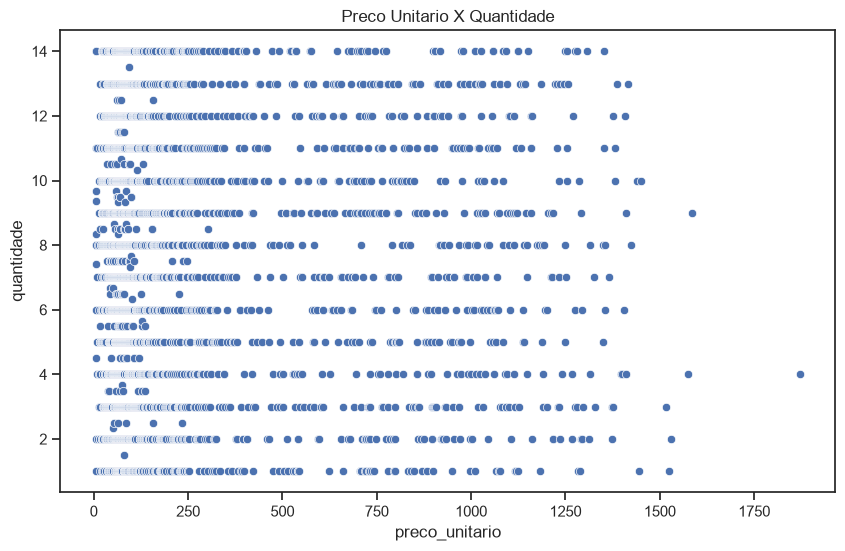

In [151]:
df_preco_quantidade = df.sample(frac=0.1).reset_index(drop=True) # extrair uma amostra aleatória com 10% dos dados
df_preco_quantidade = df_preco_quantidade[["preco_unitario","quantidade", "categoria"]]
df_preco_quantidade["outlier_preco"] = np.where(df_preco_quantidade["preco_unitario"]<2200, 1, np.nan) # retirar outliers
df_preco_quantidade["outlier_quant"] = np.where(df_preco_quantidade["quantidade"]<20, 1, np.nan)
df_preco_quantidade.dropna(subset=["outlier_preco", "outlier_quant"], inplace=True, how="any")
df_preco_quantidade = df_preco_quantidade.groupby("preco_unitario", as_index=False)["quantidade"].mean()
fig, ax = plt.subplots(figsize=(10,6))
sns.scatterplot(data=df_preco_quantidade, x="preco_unitario", y="quantidade")
plt.title("Preco Unitario X Quantidade")

#### O objetivo do gráfico acima é observar a existência de correlação entre a quantidade de produtos vendidos e seu preço unitário. Para isso, os dados foram agrupados pelo preço unitário, e então consideramos a média das quantidades vendidas. Não é possível, no entanto, observar a existência de correlação entre o preço unitário de um produto e as quantidades vendidas desse produto. Sendo assim, produtos de baixo, médio e alto preços tendem a ser vendidos em quantidades próximas umas das outras.

## D. Mapa de Calor

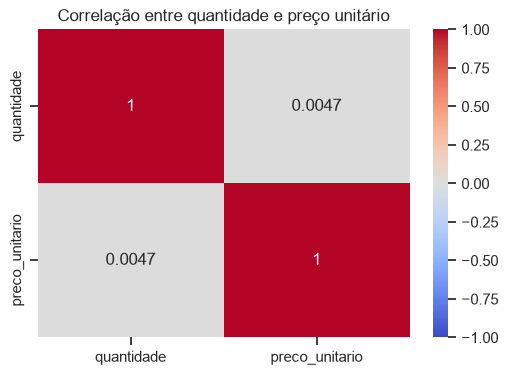

In [145]:
corr = df[["quantidade", "preco_unitario"]].corr()
plt.figure(figsize=(6,4))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlação entre quantidade e preço unitário")
plt.show()

#### Para confirmar o que foi observado no gráfico de dispersão anterior, foi feito um gráfico de calor para investigar, mais uma vez, a correlação entre o preço unitário de um produto e as quantidades vendidas desse produto. A correlação entre essas duas variáveis é de 0.0047 como aponta o gráfico acima. Esse valor indica que, de fato, essas duas variáveis não apresentam correlação significativa.

## Portanto, podemos concluir que os produtos da categoria Eletrônicos são os que geram maior receita para esse E-commerce. Os meses de novembro, dezembro e janeiro são os que geram maior volume de renda, enquanto os demais meses apresentam uma queda nessa quantidade. Procuramos pela existência de correlação entre a quantidade de vendas de um produto e o seu preço de duas maneiras: por um gráfico de dispersão dos dados e por um gráfico de calor. No entanto, foi observado que os consumidores não tendem a comprar produtos em maior quantidade se seus preços forem mais baixos, assim como não compram produtos em menor quantidade caso seus preços forem maiores.